In [1]:
# Cell 1:
import networkx as nx
import numpy as np
from queue import PriorityQueue
import ipywidgets as widgets
from copy import deepcopy
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque, defaultdict
import matplotlib.pyplot as plt
from IPython.display import display, clear_output, HTML
import logging
import dgl 
import os 
import random 
import itertools
from utils.model_utils import *

# Giả định basic_utils.py chứa MỌI THỨ từ file Original.ipynb
# (MultiHeadDQN, NetworkEnv, ReplayBuffer, evaluate_model, v.v.)
from utils.attack_algo_utils import *
from utils.graph_utils import *
from utils.basic_utils import *

# --- CUDA DEVICE SETUP ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Cell 2:
import logging
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

# Configure logging to output to PyCharm's console
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler()]
)
logger = logging.getLogger(__name__)

# def add_node_with_edges(graph, node_name):
#     """
#     Thêm một node vào đồ thị.
#     Giai đoạn 1: Cho phép người dùng nhập 'priority' cho node mới.
#     Giai đoạn 2: Cho phép người dùng nhập các cạnh liên quan.
#     """
#     # Thêm node (chưa có thuộc tính)
#     graph.add_node(node_name)
#
#     # Khai báo các widget toàn cục cho hàm này
#     global node_dropdown, user_text, root_text, direction_dropdown, output, priority_text_widget
#     output = widgets.Output()
#
#     # --- Giai đoạn 2: Logic thêm cạnh (Giữ nguyên) ---
#     def add_edge(b):
#         with output:
#             # (Lấy priority đã lưu để hiển thị lại thông báo)
#             current_priority = graph.nodes[node_name].get('priority', 'N/A')
#             priority_msg = f"<b>Node:</b> '{node_name}' (Priority={current_priority}).<br><b>Adding Edges:</b>"
#
#             clear_output(wait=True)
#             display(HTML(priority_msg))
#             logger.info(f"Add Edge button clicked for node '{node_name}'.")
#
#             try:
#                 target_node = node_dropdown.value
#                 user_prob = float(user_text.value)
#                 root_prob = float(root_text.value)
#                 direction = direction_dropdown.value
#
#                 if not (0.0 <= user_prob <= 1.0 and 0.0 <= root_prob <= 1.0):
#                     display(HTML("<b>Error:</b> Probabilities must be in the range [0.0, 1.0]. Please try again."))
#                     logger.error(f"Invalid probabilities: user={user_prob}, root={root_prob}")
#                     # Hiển thị lại widget nếu lỗi
#                     display_widgets(priority_msg)
#                     return
#
#                 edge_info = f"Edge Info: user={user_prob}, root={root_prob}, direction={direction}"
#
#                 if direction == "To Target":
#                     graph.add_edge(node_name, target_node, user=user_prob, root=root_prob)
#                     edge_msg = f"Edge from '{node_name}' to '{target_node}' ({edge_info})"
#                 elif direction == "From Target":
#                     graph.add_edge(target_node, node_name, user=user_prob, root=root_prob)
#                     edge_msg = f"Edge from '{target_node}' to '{node_name}' ({edge_info})"
#                 else:  # Bidirectional
#                     graph.add_edge(node_name, target_node, user=user_prob, root=root_prob)
#                     graph.add_edge(target_node, node_name, user=user_prob, root=root_prob)
#                     edge_msg = f"Bidirectional edge between '{node_name}' and '{target_node}' ({edge_info})"
#
#                 display(HTML(f"<b>Notification:</b> {edge_msg} has been added."))
#                 logger.info(f"{edge_msg} has been added.")
#                 # Hiển thị lại widget cho cạnh tiếp theo
#                 display_widgets(priority_msg)
#             except ValueError:
#                 display(HTML("<b>Error:</b> Invalid input for probabilities. Please enter valid numbers."))
#                 logger.error("Invalid input for probabilities.")
#
#     def stop_adding(b):
#         with output:
#             clear_output(wait=True)
#             display(HTML(f"<b>Notification:</b> Finished adding edges for node '{node_name}'."))
#             logger.info(f"Finished adding edges for node '{node_name}'.")
#
#     def display_widgets(priority_msg):
#         """Hàm hiển thị Giao diện Giai đoạn 2 (Thêm cạnh)"""
#         with output:
#             clear_output(wait=True)
#             display(HTML(priority_msg)) # Hiển thị lại thông báo node và priority
#
#             existing_nodes = list(graph.nodes())
#             if not existing_nodes:
#                 display(HTML("<b>Warning:</b> No existing nodes in the graph."))
#                 logger.warning("No existing nodes in the graph.")
#                 return
#
#             global node_dropdown, user_text, root_text, direction_dropdown
#             node_dropdown = widgets.Dropdown(options=existing_nodes, description='Target Node:', disabled=False)
#             user_text = widgets.FloatText(value=0.0, description='User Prob:', style={'description_width': 'initial'})
#             root_text = widgets.FloatText(value=0.0, description='Root Prob:', style={'description_width': 'initial'})
#             direction_dropdown = widgets.Dropdown(options=["To Target", "From Target", "Bidirectional"], description='Edge Direction:', disabled=False)
#             add_button = widgets.Button(description="Add Edge")
#             stop_button = widgets.Button(description="Stop")
#
#             add_button.on_click(add_edge)
#             stop_button.on_click(stop_adding)
#
#             display(node_dropdown, user_text, root_text, direction_dropdown, add_button, stop_button)
#
#     # --- Giai đoạn 1: Logic thêm Priority (Mới) ---
#     def set_priority(b):
#         """Xử lý việc gán priority và chuyển sang Giai đoạn 2"""
#         with output:
#             try:
#                 # Lấy giá trị float (hoặc int nếu bạn muốn)
#                 priority_value = float(priority_text_widget.value)
#
#                 # Gán thuộc tính 'priority' cho node
#                 graph.nodes[node_name]['priority'] = priority_value
#
#                 msg = f"<b>Notification:</b> Node '{node_name}' added with priority={priority_value}."
#                 logger.info(f"Node '{node_name}' priority set to {priority_value}.")
#
#                 # Chuyển sang Giai đoạn 2 (Thêm cạnh)
#                 # Truyền thông báo mới vào display_widgets
#                 display_widgets(f"{msg}<br><b>Now adding edges:</b>")
#
#             except ValueError:
#                 clear_output(wait=True)
#                 display(HTML("<b>Error:</b> Invalid priority. Please enter a valid number."))
#                 logger.error("Invalid input for priority.")
#                 # Thử lại Giai đoạn 1
#                 display_priority_widget()
#
#     def display_priority_widget():
#         """Hàm hiển thị Giao diện Giai đoạn 1 (Thêm Priority)"""
#         with output:
#             clear_output(wait=True)
#             display(HTML(f"<b>Notification:</b> Node '{node_name}' has been added."))
#             display(HTML(f"<b>Please set priority for '{node_name}':</b>"))
#
#             global priority_text_widget
#             priority_text_widget = widgets.FloatText(
#                 value=0.0, # Giá trị priority mặc định
#                 description='Priority:',
#                 style={'description_width': 'initial'}
#             )
#
#             set_priority_button = widgets.Button(description="Set Priority & Add Edges")
#             set_priority_button.on_click(set_priority)
#
#             display(priority_text_widget, set_priority_button)
#
#     # --- Khởi chạy ---
#     # Bắt đầu bằng cách hiển thị Giai đoạn 1 (Thêm Priority)
#     display(output)
#     display_priority_widget()

In [3]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import logging

# Cấu hình logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

def disable_edge_weights_ui(graph):
    """
    Giao diện chọn cạnh và gán trọng số (user, root) về 0.0
    thay vì xóa cạnh khỏi đồ thị.
    """

    output_disable = widgets.Output()
    all_nodes = list(graph.nodes())

    if not all_nodes:
        print("Đồ thị rỗng.")
        return

    # --- Widgets ---
    source_dropdown = widgets.Dropdown(
        options=all_nodes,
        description='Source Node:',
        style={'description_width': 'initial'}
    )

    target_dropdown = widgets.Dropdown(
        options=[],
        description='Target Node:',
        style={'description_width': 'initial'},
        disabled=True
    )

    # Nút bấm đổi tên thành "Set Weight 0" cho rõ nghĩa
    btn_disable = widgets.Button(
        description='Set Weight -1',
        button_style='warning', # Màu cam
        icon='eraser'
    )

    # --- Logic ---
    def on_source_change(change):
        if change['type'] == 'change' and change['name'] == 'value':
            u = change['new']
            if u in graph:
                # Lấy danh sách các node mà u trỏ tới
                neighbors = list(graph.neighbors(u))
                if neighbors:
                    target_dropdown.options = neighbors
                    target_dropdown.disabled = False
                    target_dropdown.value = neighbors[0]
                else:
                    target_dropdown.options = []
                    target_dropdown.disabled = True

    def on_disable_click(b):
        with output_disable:
            clear_output(wait=True)
            u = source_dropdown.value
            v = target_dropdown.value

            if u is None or v is None:
                display(HTML("<b>Error:</b> Please select nodes."))
                return

            if graph.has_edge(u, v):
                # --- THAY ĐỔI CHÍNH Ở ĐÂY ---
                # Thay vì remove_edge, ta cập nhật attributes
                graph[u][v]['user'] = -1.0
                graph[u][v]['root'] = -1.0

                # Kiểm tra lại để xác nhận
                new_data = graph[u][v]

                msg = (f"<b>Updated:</b> Edge '{u}' &rarr; '{v}' weights set to 0.<br>"
                       f"<i>Current attributes: {new_data}</i>")
                logger.info(f"Set weights to 0 for edge ({u}, {v})")
                display(HTML(msg))
            else:
                display(HTML(f"<b>Error:</b> Edge ({u}, {v}) not found."))

    # --- Wiring ---
    source_dropdown.observe(on_source_change, names='value')
    btn_disable.on_click(on_disable_click)

    # Init
    if all_nodes:
        # Trigger update lần đầu
        class MockChange:
            def __getitem__(self, key):
                return 'value' if key == 'name' else ('change' if key == 'type' else all_nodes[0])
        on_source_change({'type': 'change', 'name': 'value', 'new': all_nodes[0]})

    display(HTML("<h3>Disable Edge Interface (Set Weights = -1)</h3>"))
    display(source_dropdown, target_dropdown, btn_disable, output_disable)

# Chạy giao diện


In [4]:
# Cell 3: Load đồ thị từ file graph_environment.pth thay vì định nghĩa lại

# Đường dẫn đến file môi trường đã lưu trong Original.ipynb
# Lưu ý: Kiểm tra lại experiment_id nếu bạn đã thay đổi nó trong Original.ipynb (mặc định là '1')
experiment_id = 1
graph_env_path = f'graphs/{experiment_id}/graph_environment.pth'

if os.path.exists(graph_env_path):
    print(f"Dang tai do thi tu: {graph_env_path}")

    # Load dữ liệu sử dụng torch
    # weights_only=False là cần thiết vì ta đang load cả cấu trúc đồ thị NetworkX
    env_data = torch.load(graph_env_path, map_location=device, weights_only=False)

    # Lấy đồ thị gốc đã lưu (key là 'G' như trong hàm save_graph_env)
    G_1 = env_data['G']

    print(f"Load thanh cong G_1: {G_1.number_of_nodes()} nodes, {G_1.number_of_edges()} edges")

    # (Tùy chọn) Kiểm tra xem các thuộc tính quan trọng có tồn tại không
    # print("Node attributes:", G_1.nodes(data=True))
else:
    raise FileNotFoundError(f"Khong tim thay file: {graph_env_path}. Hay chay 'save_graph_env' trong Original.ipynb truoc.")

# Tạo bản sao để thêm node mới cho phần Bias Correction
G_new = G_1.copy()

Dang tai do thi tu: graphs/1/graph_environment.pth
Load thanh cong G_1: 8 nodes, 56 edges


In [5]:
 # Chỉnh sửa đồ thị mới
# add_node_with_edges(G_new, "New node")
disable_edge_weights_ui(G_new)

Dropdown(description='Source Node:', options=('Data Server', 'Pad', 'Web Server', 'Host 1', 'Host 2', 'Host 3'…

Dropdown(description='Target Node:', options=('File Server', 'Router', 'Pad', 'Web Server', 'Host 1', 'Host 2'…

Button(button_style='warning', description='Set Weight -1', icon='eraser', style=ButtonStyle())

Output()

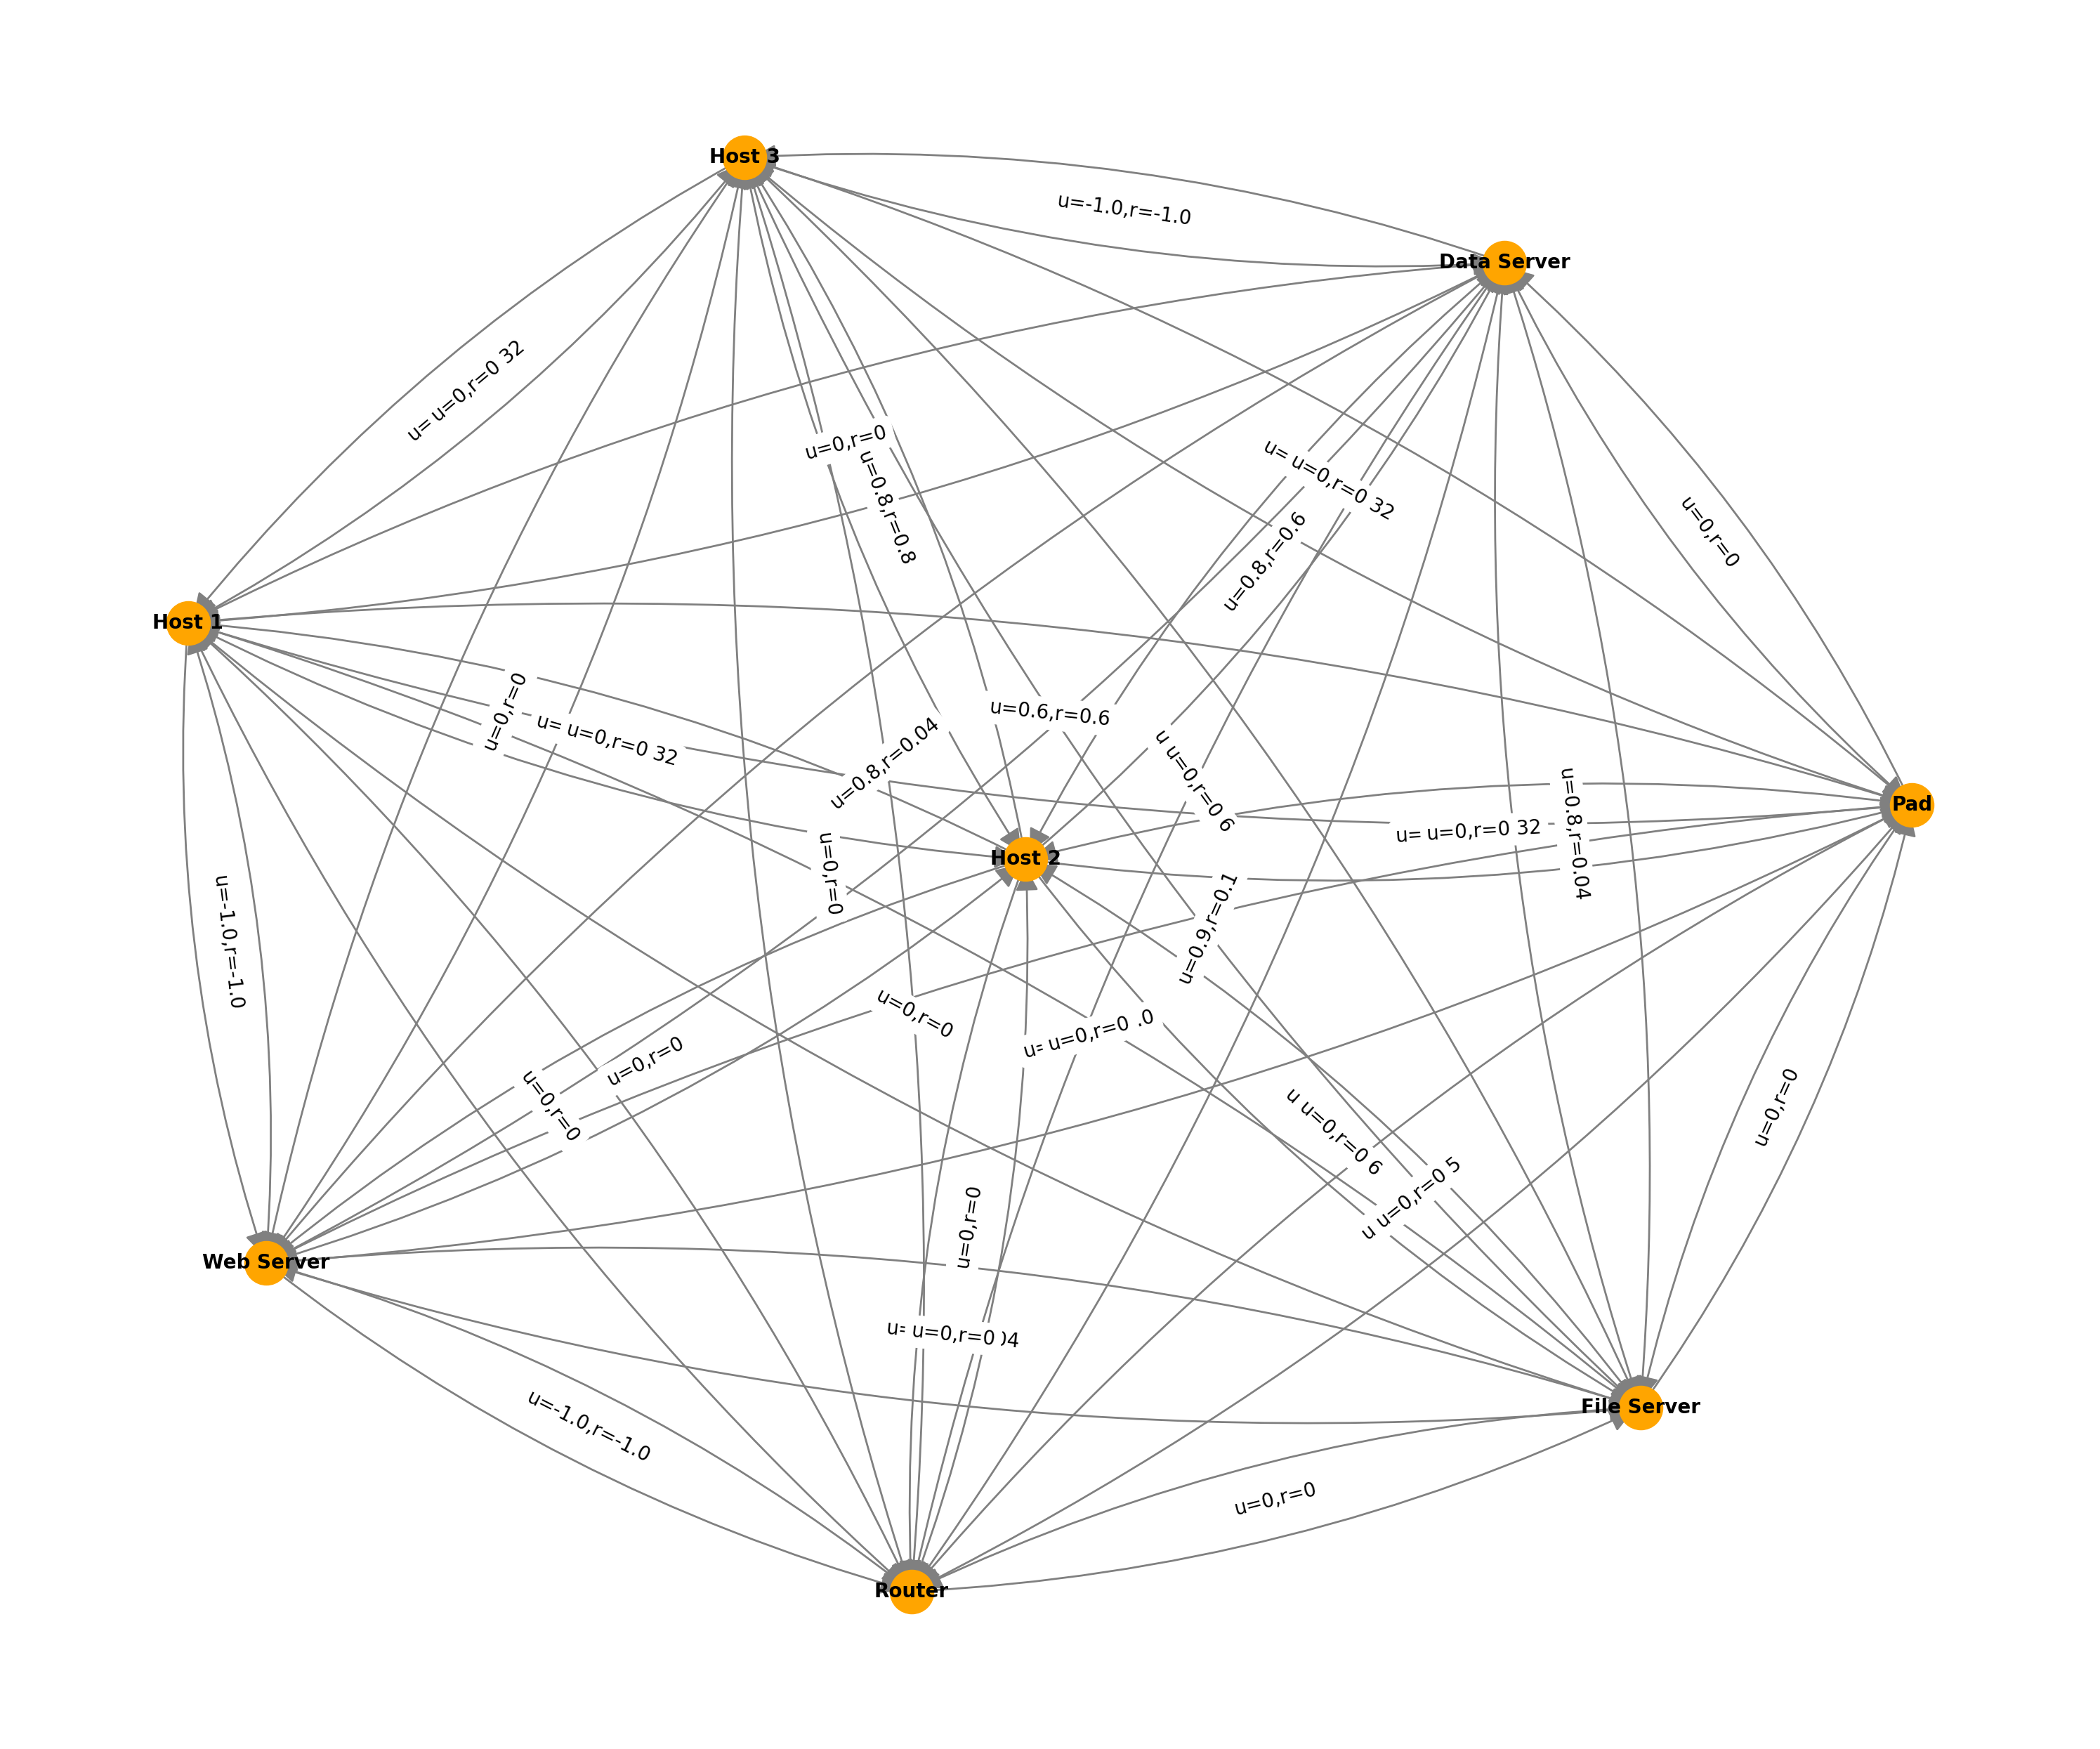

In [6]:
# Cell 4:
plt.figure(figsize=(30, 25))

# Cố định layout để lần nào cũng ra vị trí giống nhau
pos = nx.spring_layout(G_new, seed=42)

# Vẽ nodes
nx.draw_networkx_nodes(G_new, pos, node_color='orange', node_size=2000)

# Vẽ labels nodes
nx.draw_networkx_labels(G_new, pos, font_size=20, font_weight='bold')

# Vẽ edges với mũi tên và màu xám
nx.draw_networkx_edges(
    G_new, pos,
    edge_color='gray',
    arrows=True,
    arrowsize=50,
    width=2,
    connectionstyle='arc3,rad=0.1'  # Cạnh hơi cong cho đẹp
)

# Vẽ label trọng số cạnh
edge_labels = {(u, v): f"u={d['user']},r={d['root']}" for u, v, d in G_new.edges(data=True)}
nx.draw_networkx_edge_labels(G_new, pos, edge_labels=edge_labels, font_size=20)

plt.axis('off')
plt.tight_layout()

plt.savefig("graph_new.png") # Đổi tên file để không ghi đè
plt.show()


In [7]:
# Cell 5: Tải Cấu hình và GNN Encoder (Đã đồng bộ với Graph.ipynb)
import yaml
import torch
import torch.nn.functional as F
from utils.graph_utils import EGraphSAGE, DGI # Giả định class nằm ở đây

print("\n--- Đang tải cấu hình và trọng số GNN ---")

# Định nghĩa đường dẫn (Khớp với Graph.ipynb cell 10)
BASE_PATH = 'graphs'
OLD_EXP_ID = 1
MODEL_STATE_PATH = f"{BASE_PATH}/dgi_model_state_dict.pth"
CONFIG_FILE_PATH = f"{BASE_PATH}/model_config.yaml"
OLD_DQN_PATH = f"{BASE_PATH}/{OLD_EXP_ID}/dqn_model.pth"
# File này chứa dữ liệu gốc từ Graph.ipynb (node features cũ)
# Lưu ý: Bạn cần chắc chắn file này tồn tại hoặc lấy từ logic của Graph.ipynb
STATIC_ENV_PATH = f"{BASE_PATH}/{OLD_EXP_ID}/graph_environment.pth"

# --- 2. TẢI MODEL GNN ---
try:
    # Load Config
    with open(CONFIG_FILE_PATH, 'r') as f:
        config = yaml.safe_load(f)
    print(f"Loaded GNN Config: {config}")

    # Khởi tạo Encoder
    encoder = EGraphSAGE(
        config['NDIM_IN'],
        config['EDIM'],
        config['N_HIDDEN'],
        config['N_OUT'],
        config['N_LAYERS'],
        F.leaky_relu,
        device
    )

    # Load trọng số
    dgi_model_to_load = DGI(encoder)
    # weights_only=False để tránh cảnh báo trên PyTorch mới, map_location để tránh lỗi device
    dgi_model_to_load.load_state_dict(torch.load(MODEL_STATE_PATH, map_location=device, weights_only=False))

    # Trích xuất Encoder & Freeze (quan trọng cho RL)
    trained_encoder = dgi_model_to_load.encoder
    trained_encoder.to(device)
    trained_encoder.eval() # Chế độ suy luận
    for param in trained_encoder.parameters():
        param.requires_grad = False # Không train lại GNN trong lúc train RL

    # Thiết lập thông số môi trường
    embedding_dim = config['N_OUT']
    MAX_N_FEATURES = config['NDIM_IN']
    MAX_E_FEATURES = config['EDIM']

    # Hàm tiền xử lý (Cần thiết cho NetworkEnv)
    def build_batch_tensor(feats, max_dim):
        return feats[:, :max_dim]

    print(f"[THÀNH CÔNG] Đã tải GNN encoder. Embedding dim: {embedding_dim}")

    if os.path.exists(OLD_DQN_PATH):
        print(f"[THÔNG BÁO] Tìm thấy DQN model cũ tại: {OLD_DQN_PATH}")
    else:
        print(f"[CẢNH BÁO] Không tìm thấy file DQN model cũ tại: {OLD_DQN_PATH}")

except Exception as e:
    print(f"\n[LỖI] Có vấn đề khi tải GNN encoder: {e}")
    trained_encoder = None


--- Đang tải cấu hình và trọng số GNN ---
Loaded GNN Config: {'EDIM': 2, 'NDIM_IN': 2, 'N_HIDDEN': 16, 'N_LAYERS': 2, 'N_OUT': 24}
[THÀNH CÔNG] Đã tải GNN encoder. Embedding dim: 24
[THÔNG BÁO] Tìm thấy DQN model cũ tại: graphs/1/dqn_model.pth


In [8]:
# Cell 7: Thiết lập Môi trường Mới & Transfer Learning (Đã sửa đổi)
from copy import deepcopy
import dgl
import torch
import numpy as np

# --- 1. Tải dữ liệu môi trường CŨ ---# Cần thiết để biết mapping cũ
    # Sử dụng STATIC_ENV_PATH đã định nghĩa ở Cell 5
env_data = torch.load(STATIC_ENV_PATH, weights_only=False)
node_map_static = env_data['node_map']

# --- 2. Xử lý Đồ thị Mới (G_new từ Cell 3) ---
# G_new đã có node mới "New node"

# 2.1. Cập nhật Node Map
node_map_new = node_map_static.copy()
new_nodes_list = []

# Duyệt qua tất cả node trong G_new để tìm node mới
for node in G_new.nodes():
    if node not in node_map_new:
        new_idx = len(node_map_new)
        node_map_new[node] = new_idx
        new_nodes_list.append(node)

M_old = len(node_map_static)
M_new = len(node_map_new)

print(f"Node Map Mới (M={M_new}): {node_map_new}")
print(f"Các node mới thêm vào: {new_nodes_list}")

# 2.2. Tạo Feature Tensor (Chuẩn hóa cho GNN)
# Lấy danh sách node theo đúng thứ tự index mới
node_order_new = [None] * M_new
for name, idx in node_map_new.items():
    node_order_new[idx] = name

# Tạo tensor đặc trưng node [State, Priority]
nfeats_list = []
for node in node_order_new:
    # Lấy attribute từ G_new, nếu không có thì default 0
    state = G_new.nodes[node].get('state', 0.0)
    prio = G_new.nodes[node].get('priority', 0.0)
    nfeats_list.append([state, prio])

nfeats_new = torch.tensor(nfeats_list, dtype=torch.float32).to(device)
# Cắt bớt nếu feature dim > model config (ví dụ model chỉ nhận 2 feature đầu)
nfeats_new = build_batch_tensor(nfeats_new, MAX_N_FEATURES)

# Tạo tensor đặc trưng edge
src_ids = []
dst_ids = []
efeats_list = []

# B1: Lấy tất cả cạnh ra list
raw_edges = list(G_new.edges(data=True))

# B2: Sắp xếp cạnh theo timestamp (giống hệt logic trong basic_utils.py)
# Dùng .get('timestamp', 0.0) để tránh lỗi nếu cạnh cũ chưa có timestamp
raw_edges.sort(key=lambda x: x[2].get('timestamp', 0.0))

print(f"Đang xử lý {len(raw_edges)} cạnh (đã sort theo timestamp)...")

# B3: Duyệt qua danh sách đã sort để tạo DGL
for u, v, data in raw_edges:
    src_ids.append(node_map_new[u])
    dst_ids.append(node_map_new[v])
    efeats_list.append([data.get('user', 0.0), data.get('root', 0.0)])

g_dgl_new = dgl.graph((src_ids, dst_ids), num_nodes=M_new).to(device)

if efeats_list:
    efeats_new = torch.tensor(efeats_list, dtype=torch.float32).to(device)
    efeats_new = build_batch_tensor(efeats_new, MAX_E_FEATURES)
else:
    # Xử lý trường hợp không có cạnh (ít gặp)
    efeats_new = torch.zeros((0, MAX_E_FEATURES)).to(device)


# --- 3. Khởi tạo Môi trường Mới ---
# Quan trọng: Giữ nguyên max_nodes, max_edges như lúc train cũ
# để đảm bảo input size của DQN không đổi (do padding)
N_honeypots = 2
MAX_NODES_CONFIG = 24 # Lấy từ config hoặc hardcode nếu biết trước
MAX_EDGES_CONFIG = 256

env = NetworkEnv(
    G_new=G_new,
    attack_fn=global_weighted_random_attack, # Hàm tấn công từ utils
    g_dgl=g_dgl_new,
    encoder=trained_encoder, # Encoder đã load và freeze ở Cell 5
    original_node_features=nfeats_new,
    original_edge_features=efeats_new,
    node_map=node_map_new,
    num_honeypots=N_honeypots, # N=3
    max_nodes=MAX_NODES_CONFIG,
    max_edges=MAX_EDGES_CONFIG
)



print("\n[MÔI TRƯỜNG] Đã khởi tạo Env mới.")
print(f"Số node thực tế: {M_new}. Max padding: {MAX_NODES_CONFIG}")


# --- 4. Transfer Learning: Tải Model DQN Cũ ---
# Tính toán kích thước state đầu vào (dựa trên padding cố định)
# State = [Flattened Node Embeddings] + [Flattened Edge Embeddings]
# Kích thước = (max_nodes * embed_dim) + (max_edges * embed_dim)
# Lưu ý: Phải khớp logic trong NetworkEnv._get_embeddings_from_state
state_size_fixed = (MAX_NODES_CONFIG * embedding_dim) + (MAX_EDGES_CONFIG * embedding_dim)

# Khởi tạo model với kích thước cố định (như lúc train cũ)
# Action output vẫn là MAX_NODES_CONFIG (24), nhưng ta sẽ mask các node > M_new
dqn_model = MultiHeadDQN(state_size_fixed, N_honeypots, MAX_NODES_CONFIG).to(device)

try:
    # OLD_DQN_PATH đã định nghĩa ở Cell 5
    checkpoint = torch.load(OLD_DQN_PATH, map_location=device, weights_only=False)

    # Load state dict
    # Nếu bạn lưu cả optimizer, chỉ lấy phần 'policy_net_state_dict'
    if 'policy_net_state_dict' in checkpoint:
        dqn_model.load_state_dict(checkpoint['policy_net_state_dict'])
    else:
        dqn_model.load_state_dict(checkpoint)

    print(f"[TRANSFER] Đã tải trọng số từ: {OLD_DQN_PATH}")
except Exception as e:
    print(f"[LỖI] Không tải được model cũ: {e}")
    # Nếu lỗi, dqn_model sẽ là random init (học từ đầu)


Node Map Mới (M=8): {'Data Server': 0, 'Pad': 1, 'Web Server': 2, 'Host 1': 3, 'Host 2': 4, 'Host 3': 5, 'File Server': 6, 'Router': 7}
Các node mới thêm vào: []
Đang xử lý 56 cạnh (đã sort theo timestamp)...
node_to_idx đã được tải: {'Data Server': 0, 'Pad': 1, 'Web Server': 2, 'Host 1': 3, 'Host 2': 4, 'Host 3': 5, 'File Server': 6, 'Router': 7}
Mục tiêu (Goals) được thiết lập: ['Data Server']
Số lượng honeypot (N) được thiết lập: 2
Số lượng nút đặt (M) được thiết lập: 8

[MÔI TRƯỜNG] Đã khởi tạo Env mới.
Số node thực tế: 8. Max padding: 24
[TRANSFER] Đã tải trọng số từ: graphs/1/dqn_model.pth


In [9]:
def train_dqn_finetune(
    env,
    policy_net,
    target_net,
    optimizer,
    replay_buffer,
    num_episodes,
    device=None,
    batch_size=64,
    gamma=0.99,
    tau=0.005,
    freeze_encoder_steps=2000,
    stability_coef=0.1
):
    """
    Fine-tune DQN khi đã load model cũ.

    - policy_net, target_net, optimizer, replay_buffer -> truyền từ ngoài vào
    - Giữ Q-value ổn định bằng stability loss
    - Freeze encoder tạm thời để tránh sốc vì thay đổi input graph
    """

    global best_checkpoint, best_episode

    # Ensure on correct device
    policy_net = policy_net.to(device)
    target_net = target_net.to(device)
    target_net.eval()

    total_reward = 0
    dsp = 0
    best_dsp = 0
    best_checkpoint = None
    global_step = 0

    interval_check = max(1, num_episodes // 10)
    interval_save = max(1, num_episodes // 5)

    for episode in range(1, num_episodes + 1):

        state = env.reset().to(device)
        done = False
        current_num_nodes = len(env.nodes)

        while not done:

            # -------------------------
            # SELECT ACTION
            # -------------------------
            with torch.no_grad():
                state_tensor = state.flatten().unsqueeze(0)
                q_values = policy_net(state_tensor)

                if current_num_nodes < q_values.shape[-1]:
                    q_values[:, :, current_num_nodes:] = -float("inf")

                action = select_action_multi_head(q_values.squeeze(0), current_num_nodes)

            # STEP
            next_state, reward, done, path, captured = env.step(action)
            next_state = next_state.to(device)

            replay_buffer.push(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
            if reward == 1:
                dsp += 1
            global_step += 1


            # TRAINING
            # -------------------------
            if len(replay_buffer) >= batch_size:

                states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

                states = states.to(device).flatten(start_dim=1)
                next_states = next_states.to(device).flatten(start_dim=1)
                actions = actions.to(device)
                rewards = rewards.to(device)
                dones = dones.to(device)

                # 1. CURRENT Q(s,a)
                q_values_all = policy_net(states)
                current_q = (q_values_all * actions).sum(dim=2).sum(dim=1)

                # 2. DOUBLE DQN TARGET
                with torch.no_grad():

                    next_policy_q = policy_net(next_states)

                    if current_num_nodes < next_policy_q.shape[-1]:
                        next_policy_q[:, :, current_num_nodes:] = -float("inf")

                    next_act = next_policy_q.argmax(dim=2, keepdim=True)
                    next_target_q = target_net(next_states).gather(2, next_act).squeeze(2)

                    next_q_total = next_target_q.sum(dim=1)
                    targets = rewards.squeeze(1) + (1 - dones.squeeze(1)) * gamma * next_q_total

                # -------------------------
                # 3. Q-LOSS
                # -------------------------
                with torch.no_grad():
                    old_q = target_net(states)

                # stability_loss = stability_coef * nn.MSELoss()(q_values_all, old_q)

                # loss = td_loss + stability_loss
                loss = nn.MSELoss()(current_q, targets)
                # -------------------------
                # 5. BACKPROP
                # -------------------------
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 1.0)
                optimizer.step()

                # -------------------------
                # 6. SOFT UPDATE TARGET
                # -------------------------
                for t, p in zip(target_net.parameters(), policy_net.parameters()):
                    t.data.copy_(t.data * (1 - tau) + p.data * tau)

        # LOG
        if episode % interval_check == 0:
            print(f"[FineTune] Episode {episode}, Total Reward={total_reward}, DSP={dsp / interval_check * 100:.2f}%")
            total_reward = 0

            if dsp > best_dsp:
                best_dsp = dsp
                best_episode = episode
                best_checkpoint = {
                    "policy_net_state_dict": deepcopy(policy_net.state_dict()),
                    "target_net_state_dict": deepcopy(target_net.state_dict()),
                    "optimizer_state_dict": deepcopy(optimizer.state_dict()),
                }

            dsp = 0

        # SAVE
        if (episode + 1) % interval_save == 0 and best_checkpoint is not None:
            os.makedirs("./Saved_Model", exist_ok=True)
            torch.save(
                {
                    "policy_net_state_dict": best_checkpoint["policy_net_state_dict"],
                    "target_net_state_dict": best_checkpoint["target_net_state_dict"],
                    "optimizer_state_dict": best_checkpoint["optimizer_state_dict"],
                    "episode": best_episode,
                },
                "./Saved_Model/dqn_finetuned.pth",
            )
            print(f"Saved finetuned model. Best DSP={best_dsp}")
            best_dsp = 0
            best_checkpoint = None

    return policy_net


In [10]:
optimizer = optim.Adam(dqn_model.parameters(), lr=0.0005)
replay_buffer = ReplayBuffer(capacity=4000)

model = train_dqn_finetune(env, dqn_model, dqn_model,optimizer, replay_buffer,256, device )

tensor([[-0.0037, -0.0032, -0.0029,  ...,  0.7679, -0.0036,  0.6998],
        [-0.0042, -0.0040, -0.0033,  ...,  0.8389, -0.0043,  0.7898],
        [-0.0042, -0.0040, -0.0033,  ...,  0.8389, -0.0043,  0.7898],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
       device='cuda:0')
[FineTune] Episode 25, Total Reward=-3, DSP=44.00%
[FineTune] Episode 50, Total Reward=3, DSP=56.00%
Saved finetuned model. Best DSP=14
[FineTune] Episode 75, Total Reward=5, DSP=60.00%
[FineTune] Episode 100, Total Reward=7, DSP=64.00%
Saved finetuned model. Best DSP=16
[FineTune] Episode 125, Total Reward=-3, DSP=44.00%
[FineTune] Episode 150, Total Reward=15, DSP=80.00%
Saved finetuned model. Best DSP=20
[FineTune] Episode 175, Total Reward=-3, DSP=44.00%
[FineTune] Episode 200, Total Reward=-5, DSP=40.00%
Saved finetuned model. Best

In [11]:
# Cell 14:
# Đánh giá model cuối cùng (wrapper model đã hiệu chỉnh)
print("\n--- Đánh giá Model sau khi hiệu chỉnh Bias ---")
evaluate_model(model, env, num_episodes=1000, device=device)


--- Đánh giá Model sau khi hiệu chỉnh Bias ---
Đang đánh giá trên device: cuda
Đang đánh giá... Kiến trúc Multi-Head (N=2 honeypots, M=8 nút)
--- Episode 50: Failed ---
['Pad', 'Router', 'Data Server']
Honeypots connected to: ['Web Server', 'Host 1']

--- Episode 100: Success ---
['Pad', 'Host 1', 'Honeypot {Host 1}']
Honeypots connected to: ['Web Server', 'Host 1']

Đã hoàn thành 100/1000 episodes...
--- Episode 150: Success ---
['Web Server', 'Honeypot {Web Server}']
Honeypots connected to: ['Web Server', 'Host 1']

--- Episode 200: Failed ---
['Web Server', 'Router', 'Data Server']
Honeypots connected to: ['Web Server', 'Host 1']

Đã hoàn thành 200/1000 episodes...
--- Episode 250: Failed ---
['Pad', 'Host 3', 'File Server', 'Host 2', 'Data Server']
Honeypots connected to: ['Web Server', 'Host 1']

--- Episode 300: Failed ---
['Pad', 'Host 1', 'Router', 'Host 2', 'Host 3', 'File Server', 'Data Server']
Honeypots connected to: ['Web Server', 'Host 1']

Đã hoàn thành 300/1000 episode